<a href="https://colab.research.google.com/github/Shah-Shawon/Deep-Learing-Assignments/blob/main/DL_assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision matplotlib pillow seaborn

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models

print("Libraries loaded successfully.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
os.makedirs("output", exist_ok=True)

Libraries loaded successfully.
Torch version: 2.10.0+cpu
CUDA available: False
Device: cpu


In [2]:
# Input feature map: 4 x 4 x 2
X = np.arange(1, 4*4*2 + 1).reshape(4, 4, 2)

# Kernel: 2 x 2 x 2
K = np.array([
    [[1, 0],
     [0, -1]],

    [[-1, 1],
     [1, 0]]
], dtype=float)

print("Input feature map X (4x4x2):")
print(X)
print("\nKernel K (2x2x2):")
print(K)

Input feature map X (4x4x2):
[[[ 1  2]
  [ 3  4]
  [ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]
  [13 14]
  [15 16]]

 [[17 18]
  [19 20]
  [21 22]
  [23 24]]

 [[25 26]
  [27 28]
  [29 30]
  [31 32]]]

Kernel K (2x2x2):
[[[ 1.  0.]
  [ 0. -1.]]

 [[-1.  1.]
  [ 1.  0.]]]


In [3]:
def regular_conv_3d_valid_stride(x, k, stride=1, pad=0):
    xpad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="constant")
    H, W, C = xpad.shape
    kh, kw, kc = k.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    out = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            patch = xpad[i*stride:i*stride+kh, j*stride:j*stride+kw, :]
            out[i, j] = np.sum(patch * k)
    return out

out1 = regular_conv_3d_valid_stride(X, K, stride=2, pad=0)

print("Part A1: Regular convolution, no padding, stride=2")
print("Output size = floor((4 - 2)/2) + 1 = 2 x 2")
print("Output feature map:")
print(out1)

Part A1: Regular convolution, no padding, stride=2
Output size = floor((4 - 2)/2) + 1 = 2 x 2
Output feature map:
[[ 9. 13.]
 [25. 29.]]


In [4]:
out2 = regular_conv_3d_valid_stride(X, K, stride=2, pad=1)

print("Part A2: Regular convolution, padding=1, stride=2")
print("Output size = floor((4 + 2*1 - 2)/2) + 1 = 3 x 3")
print("Output feature map:")
print(out2)

Part A2: Regular convolution, padding=1, stride=2
Output size = floor((4 + 2*1 - 2)/2) + 1 = 3 x 3
Output feature map:
[[  1.   6.   1.]
 [  7.  19.  16.]
 [-26.  -3.  31.]]


In [5]:
# Depthwise convolution means one 2x2 kernel per channel
depthwise_out = []
for c in range(2):
    xch = X[:, :, c]
    kch = K[:, :, c]
    out_ch = np.zeros((3, 3), dtype=float)
    for i in range(3):
        for j in range(3):
            patch = xch[i:i+2, j:j+2]
            out_ch[i, j] = np.sum(patch * kch)
    depthwise_out.append(out_ch)

depthwise_out = np.stack(depthwise_out, axis=-1)

print("Part A3: Depthwise convolution, no padding, stride=1")
print("Output size per channel = (4 - 2) + 1 = 3 x 3")
print("Channel 1 output:")
print(depthwise_out[:, :, 0])
print("Channel 2 output:")
print(depthwise_out[:, :, 1])

Part A3: Depthwise convolution, no padding, stride=1
Output size per channel = (4 - 2) + 1 = 3 x 3
Channel 1 output:
[[ 3.  5.  7.]
 [11. 13. 15.]
 [19. 21. 23.]]
Channel 2 output:
[[6. 6. 6.]
 [6. 6. 6.]
 [6. 6. 6.]]


In [6]:
# Use your face image. Put the file name in the same folder as Colab upload.
# If your uploaded file has a different name, change it here.
face_path = "image.jpg"

img = Image.open(face_path).convert("RGB")
print("Loaded image size:", img.size)

img_tensor = transforms.ToTensor()(img).unsqueeze(0)

kernels = {
    "edge_detection": np.array([
        [-1, -1, -1],
        [ 0,  0,  0],
        [ 1,  1,  1]
    ], dtype=np.float32),

    "sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32),

    "blur": np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ], dtype=np.float32) / 9.0
}

def apply_kernel_rgb(img_tensor, kernel_2d):
    k = torch.tensor(kernel_2d, dtype=torch.float32).view(1, 1, 3, 3)
    k = k.repeat(3, 1, 1, 1)
    out = F.conv2d(img_tensor, k, padding=1, groups=3)
    out = torch.clamp(out, 0, 1)
    return out

outputs = {}
for name, k in kernels.items():
    outputs[name] = apply_kernel_rgb(img_tensor, k)
    print(f"\nKernel: {name}")
    print(k)

Loaded image size: (1280, 949)

Kernel: edge_detection
[[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]

Kernel: sharpen
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]

Kernel: blur
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


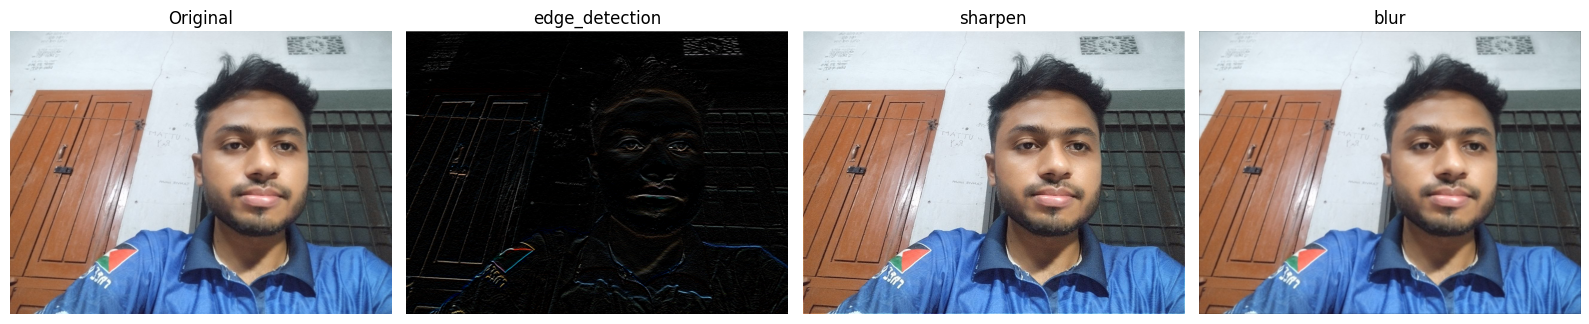

Saved: output/kernel_effects.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, (name, out) in zip(axes[1:], outputs.items()):
    out_img = out.squeeze(0).permute(1, 2, 0).detach().numpy()
    ax.imshow(out_img)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.savefig("output/kernel_effects.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: output/kernel_effects.png")

In [8]:
# 10 spatially separable kernels as outer products of two vectors
sep_vectors = [
    ([1, 1], [1, 1]),
    ([1, -1], [1, 1]),
    ([1, 2], [1, 1]),
    ([2, 1], [1, 1]),
    ([1, 0], [1, 1]),
    ([0, 1], [1, 1]),
    ([1, 3], [1, 1]),
    ([3, 1], [1, 1]),
    ([2, 2], [1, 1]),
    ([1, -2], [1, 1])
]

sep_kernels = [np.outer(a, b) for a, b in sep_vectors]

print("10 Spatially Separable Kernels")
for i, k in enumerate(sep_kernels, 1):
    print(f"\nS{i}:")
    print(k)

10 Spatially Separable Kernels

S1:
[[1 1]
 [1 1]]

S2:
[[ 1  1]
 [-1 -1]]

S3:
[[1 1]
 [2 2]]

S4:
[[2 2]
 [1 1]]

S5:
[[1 1]
 [0 0]]

S6:
[[0 0]
 [1 1]]

S7:
[[1 1]
 [3 3]]

S8:
[[3 3]
 [1 1]]

S9:
[[2 2]
 [2 2]]

S10:
[[ 1  1]
 [-2 -2]]


In [9]:
non_sep_kernels = [
    np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]]),
    np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]]),
    np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]),
    np.array([[2, -1, 0], [0, 1, -2], [1, 0, 1]]),
    np.array([[1, 0, 2], [-1, 3, 0], [0, -2, 1]]),
    np.array([[0, 2, -1], [1, 0, 1], [-2, 1, 0]]),
    np.array([[3, 1, 0], [0, -1, 2], [1, 0, -2]]),
    np.array([[1, -2, 1], [2, 0, -2], [1, -2, 1]]),
    np.array([[0, 1, -1], [2, 0, 2], [-1, 1, 0]]),
    np.array([[1, 3, 1], [-1, 0, -1], [2, 1, 2]])
]

print("10 Spatially Non-Separable Kernels")
for i, k in enumerate(non_sep_kernels, 1):
    print(f"\nN{i}:")
    print(k)

10 Spatially Non-Separable Kernels

N1:
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]

N2:
[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]

N3:
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]

N4:
[[ 2 -1  0]
 [ 0  1 -2]
 [ 1  0  1]]

N5:
[[ 1  0  2]
 [-1  3  0]
 [ 0 -2  1]]

N6:
[[ 0  2 -1]
 [ 1  0  1]
 [-2  1  0]]

N7:
[[ 3  1  0]
 [ 0 -1  2]
 [ 1  0 -2]]

N8:
[[ 1 -2  1]
 [ 2  0 -2]
 [ 1 -2  1]]

N9:
[[ 0  1 -1]
 [ 2  0  2]
 [-1  1  0]]

N10:
[[ 1  3  1]
 [-1  0 -1]
 [ 2  1  2]]


In [10]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features.to(device).eval()

first_conv = model[0].weight.detach().cpu().numpy()
print("First conv layer shape:", first_conv.shape)

# Print first few kernels
for i in range(6):
    print(f"\nKernel {i} from VGG16 first conv layer:")
    print(first_conv[i])

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 71.9MB/s]


First conv layer shape: (64, 3, 3, 3)

Kernel 0 from VGG16 first conv layer:
[[[-0.5537306   0.1427047   0.5289615 ]
  [-0.58312404  0.35655147  0.76566225]
  [-0.69022113 -0.04801885  0.48409155]]

 [[ 0.17548391  0.00986297 -0.08141315]
  [ 0.04408892 -0.07032251 -0.26035076]
  [ 0.13239175 -0.1727862  -0.1322633 ]]

 [[ 0.31302562 -0.1659134  -0.42752257]
  [ 0.47518674 -0.08267727 -0.48699915]
  [ 0.63202524  0.01930757 -0.2775303 ]]]

Kernel 1 from VGG16 first conv layer:
[[[ 0.23253721  0.12665984  0.1860546 ]
  [-0.42805314 -0.24348575  0.24628444]
  [-0.2506616   0.14177004 -0.0054864 ]]

 [[-0.14076217 -0.21902554  0.15040672]
  [-0.84126675 -0.3517562   0.5639763 ]
  [-0.24194452  0.5192758   0.5391499 ]]

 [[-0.31432396 -0.37047786 -0.13093661]
  [-0.47144184 -0.15503426  0.3458899 ]
  [ 0.05438393  0.5868277   0.49579924]]]

Kernel 2 from VGG16 first conv layer:
[[[ 0.17715041  0.5214905   0.00987399]
  [-0.27184746 -0.7170887   0.31292373]
  [-0.0757526  -0.2207885   0.334

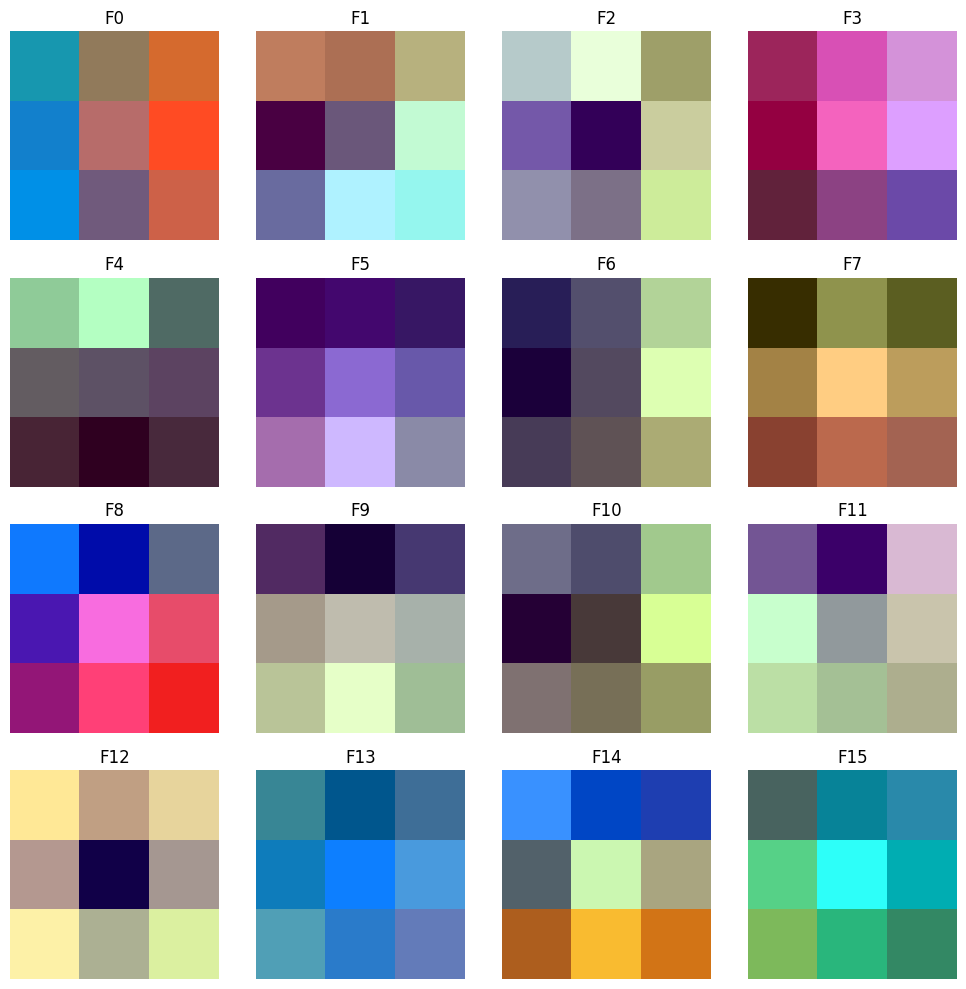

Saved: output/vgg16_kernels.png


In [11]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for idx, ax in enumerate(axes.flat):
    if idx < 16:
        ker = first_conv[idx]
        ker = np.transpose(ker, (1, 2, 0))
        ker = (ker - ker.min()) / (ker.max() - ker.min() + 1e-8)
        ax.imshow(ker)
        ax.set_title(f"F{idx}")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.savefig("output/vgg16_kernels.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: output/vgg16_kernels.png")

In [12]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_x_flat = sobel_x.flatten()
sobel_x_flat = (sobel_x_flat - sobel_x_flat.mean()) / sobel_x_flat.std()

scores = []
for idx in range(first_conv.shape[0]):
    ker = first_conv[idx].mean(axis=0)
    ker_flat = ker.flatten()
    ker_flat = (ker_flat - ker_flat.mean()) / (ker_flat.std() + 1e-8)
    corr = np.corrcoef(ker_flat, sobel_x_flat)[0, 1]
    scores.append((idx, corr))

scores = sorted(scores, key=lambda x: abs(x[1]), reverse=True)

print("Top Sobel-like kernels in VGG16 first layer:")
for idx, corr in scores[:10]:
    print(f"Filter {idx}: correlation with Sobel-X = {corr:.3f}")

Top Sobel-like kernels in VGG16 first layer:
Filter 46: correlation with Sobel-X = -0.970
Filter 17: correlation with Sobel-X = 0.969
Filter 40: correlation with Sobel-X = -0.960
Filter 6: correlation with Sobel-X = 0.958
Filter 55: correlation with Sobel-X = -0.947
Filter 31: correlation with Sobel-X = 0.899
Filter 49: correlation with Sobel-X = 0.877
Filter 63: correlation with Sobel-X = -0.845
Filter 3: correlation with Sobel-X = 0.817
Filter 10: correlation with Sobel-X = 0.810


In [13]:
with open("output/part_a_results.txt", "w") as f:
    f.write("Input X (4x4x2):\n")
    f.write(str(X) + "\n\n")
    f.write("Kernel K (2x2x2):\n")
    f.write(str(K) + "\n\n")
    f.write("Part A1 Regular conv no padding stride=2:\n")
    f.write(str(out1) + "\n\n")
    f.write("Part A2 Regular conv padding=1 stride=2:\n")
    f.write(str(out2) + "\n\n")
    f.write("Part A3 Depthwise conv channel 1:\n")
    f.write(str(depthwise_out[:, :, 0]) + "\n\n")
    f.write("Part A3 Depthwise conv channel 2:\n")
    f.write(str(depthwise_out[:, :, 1]) + "\n")

with open("output/part_c_kernels.txt", "w") as f:
    f.write("Spatially separable kernels:\n")
    for i, k in enumerate(sep_kernels, 1):
        f.write(f"S{i}:\n{k}\n\n")
    f.write("Spatially non-separable kernels:\n")
    for i, k in enumerate(non_sep_kernels, 1):
        f.write(f"N{i}:\n{k}\n\n")

print("Saved text files in output folder.")

Saved text files in output folder.
